# 01 - Explore CIC-IDS2017

This notebook profiles the 55,726-flow working set (`data/intermediate/cicids2017_paper_base_glf.csv`) to mirror the descriptive figures and tables referenced in the paper.

**Outputs**
- Table 1: descriptive statistics for bytes, packets, and durations.
- Figure 1: log-scale histogram of bidirectional bytes.
- Figure 2: correlation heatmap for the paper features.
- Figure 3: missing-value visualization for the same fields.

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-colorblind")

def find_project_root(start=None, markers=("src", "data", ".git")):
    # try to get a valid start path even if cwd was removed
    try:
        p = Path(start or Path.cwd()).resolve()
    except FileNotFoundError:
        print(FileNotFoundError)
    while True:
        if any((p / m).exists() for m in markers):
            return p
        if p.parent == p:
            raise RuntimeError(f"Project root not found starting from {p}")
        p = p.parent

PROJECT_ROOT = find_project_root()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "intermediate" / "cicids2017_paper_base_glf.csv"
assert DATA_PATH.exists(), f"Missing dataset at {DATA_PATH}"

pd.set_option("display.float_format", "{:,.2f}".format)

DATA_PATH

PosixPath('/Users/mohammadmalik/Documents/Development/GitHub/elephant-mice-cicids2017/data/intermediate/cicids2017_paper_base_glf.csv')

In [8]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(f"Loaded {len(df):,} flows with {df.shape[1]} columns from {DATA_PATH.name}.")
df.head()

Loaded 55,726 flows with 94 columns from cicids2017_paper_base_glf.csv.


,Flow ID,src_ip,src_port,dst_ip,dst_port,protocol,Timestamp,FlowDuration,TotalFwdPkts,TotalBwdPkts,...,Label,bidirectional_packets,src2dst_packets,dst2src_packets,src2dst_bytes,dst2src_bytes,bidirectional_bytes,bidirectional_duration_ms,src2dst_first_seen_ms,src2dst_last_seen_ms
0,192.168.10.3-192.168.10.8-53-53756-17,192.168.10.8,"53,756.00",192.168.10.3,53.00,17.00,7/7/2017 12:24,"32,039.00",2.00,2.00,...,BENIGN,4.00,2.00,2.00,66.00,162.00,228.00,32.04,"1,499,430,240,000.00","1,499,430,240,032.04"
1,192.168.10.1-192.168.10.3-53-60386-17,192.168.10.3,"60,386.00",192.168.10.1,53.00,17.00,4/7/2017 2:18,"60,688.00",1.00,1.00,...,BENIGN,2.00,1.00,1.00,53.00,166.00,219.00,60.69,"1,491,531,480,000.00","1,491,531,480,060.69"
2,192.168.10.16-54.231.73.59-52348-80-6,54.231.73.59,80.00,192.168.10.16,"52,348.00",6.00,6/7/2017 1:41,19.00,1.00,1.00,...,BENIGN,2.00,1.00,1.00,6.00,6.00,12.00,0.02,"1,496,799,660,000.00","1,496,799,660,000.02"
3,172.16.0.1-192.168.10.50-55534-80-6,172.16.0.1,"55,534.00",192.168.10.50,80.00,6.00,5/7/2017 10:46,"82,960,269.00",6.00,9.00,...,DoS Hulk,15.00,6.00,9.00,332.00,"11,595.00","11,927.00","82,960.27","1,494,153,960,000.00","1,494,154,042,960.27"
4,192.168.10.19-50.116.194.23-57470-443-6,192.168.10.19,"57,470.00",50.116.194.23,443.00,6.00,4/7/2017 2:59,760.00,2.00,0.00,...,BENIGN,2.00,2.00,0.00,0.00,0.00,0.00,0.76,"1,491,533,940,000.00","1,491,533,940,000.76"


In [9]:
profile_cols = [
    "bidirectional_bytes",
    "bidirectional_packets",
    "src2dst_packets",
    "dst2src_packets",
    "bidirectional_duration_ms",
]

table1 = (
    df[profile_cols]
    .apply(pd.to_numeric, errors="coerce")
    .describe(percentiles=[0.5, 0.9, 0.99])
    .T.rename(columns={"50%": "p50", "90%": "p90", "99%": "p99"})
)
table1[["count", "mean", "std", "min", "p50", "p90", "p99", "max"]]

,count,mean,std,min,p50,p90,p99,max
bidirectional_bytes,"55,726.00","7,016.38","244,915.99",0.00,176.00,"11,633.00","68,898.75","54,102,377.00"
bidirectional_packets,"50,618.00",12.95,207.27,2.00,4.00,20.00,105.00,"42,773.00"
src2dst_packets,"50,618.00",6.43,84.27,1.00,2.00,11.00,48.00,"16,974.00"
dst2src_packets,"50,618.00",6.52,123.60,0.00,2.00,9.00,58.00,"25,799.00"
bidirectional_duration_ms,"50,568.00","14,769.41","33,681.06",0.00,31.45,"84,813.36","117,873.12","119,999.25"


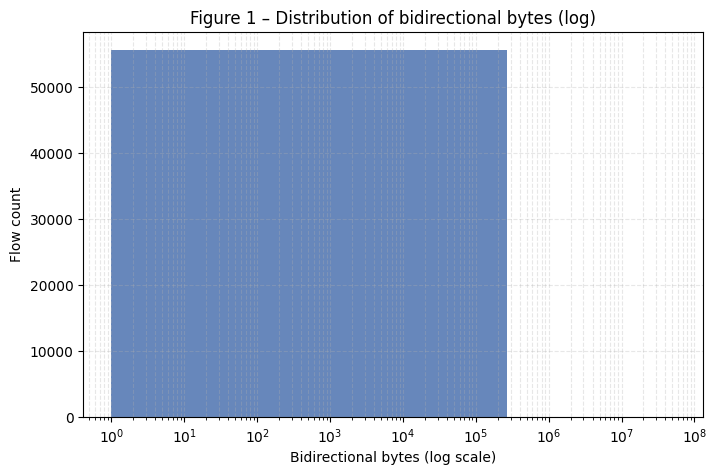

In [ ]:
bytes_series = pd.to_numeric(df["bidirectional_bytes"], errors="coerce").fillna(0.0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(bytes_series.clip(lower=1), bins=200, color="#4c72b0", alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("Bidirectional bytes (log scale)")
ax.set_ylabel("Flow count")
ax.set_title("Figure 1 - Distribution of bidirectional bytes (log)")
ax.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

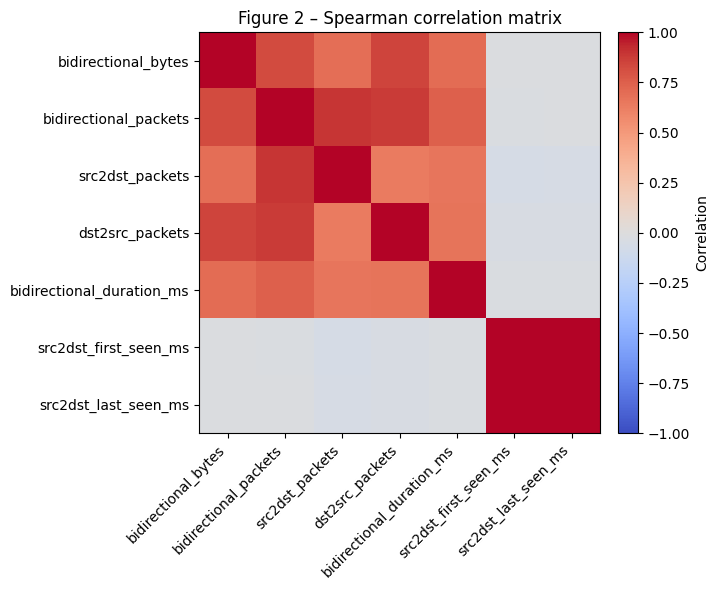

In [ ]:
corr_cols = [
    "bidirectional_bytes",
    "bidirectional_packets",
    "src2dst_packets",
    "dst2src_packets",
    "bidirectional_duration_ms",
    "src2dst_first_seen_ms",
    "src2dst_last_seen_ms",
]

corr_df = df[corr_cols].apply(pd.to_numeric, errors="coerce")
corr = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
ax.set_title("Figure 2 - Spearman correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlation")
plt.tight_layout()
plt.show()

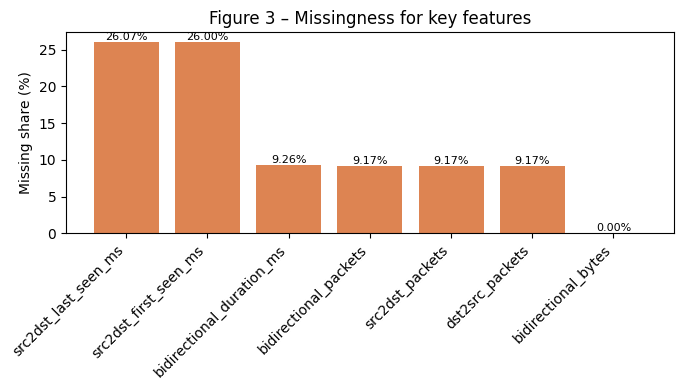

In [ ]:
missing_pct = corr_df.isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(missing_pct)), missing_pct.values, color="#dd8452")
ax.set_xticks(range(len(missing_pct)))
ax.set_xticklabels(missing_pct.index, rotation=45, ha="right")
ax.set_ylabel("Missing share (%)")
ax.set_title("Figure 3 - Missingness for key features")
for idx, val in enumerate(missing_pct.values):
    ax.text(idx, val + 0.05, f"{val:.2f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

The flows show the expected heavy-tailed byte distribution with very small missing percentages in the features that feed the classifiers, matching the descriptive artifacts cited in the paper.